<a href="https://colab.research.google.com/github/aditya-srivastava010/KAMADO-999-AI-ML-TRAINNING/blob/main/ML_LINEAR_REG_DAY_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (500, 10)
   area_sqft  bedrooms  bathrooms  age_years  floors  garage_spaces  \
0       1360         1          3         27       2              0   
1       4272         1          2         14       2              1   
2       3592         3          2         29       1              2   
3        966         5          2         36       3              0   
4       4926         4          1         28       1              0   

   distance_to_city_km  crime_rate  school_rating  price_usd  
0                  2.6        0.25              4     213500  
1                 15.9        3.85              8     526400  
2                 33.0        3.44             10     409500  
3                 47.0        0.29              7      64900  
4                 43.7        1.33              9     562000  

Class Distribution:
 price_category
High      200
Medium    179
Low        98
Luxury     23
Name: count, dtype: int64

✅ Accuracy : 0.89

Cross-Val Score (5-fold): 0.825

Classi

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


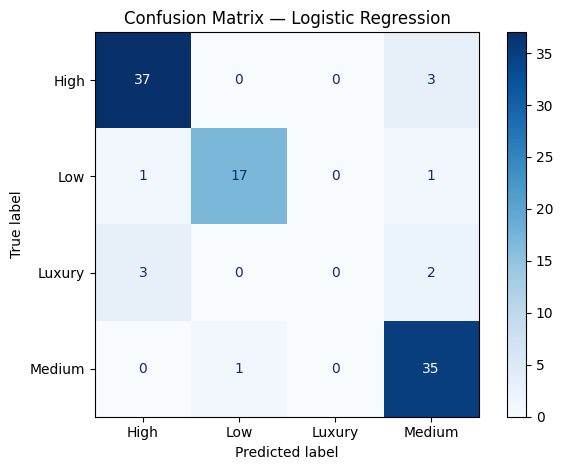


📊 Plot saved: lr_confusion_matrix.png

Coefficients per Class:
                         High       Low    Luxury    Medium
area_sqft            2.179547 -3.607697  2.545843 -1.117693
bedrooms             0.288460 -0.666741  0.660047 -0.281766
bathrooms            0.203169 -0.282769  0.191648 -0.112049
age_years           -0.524360  0.990552 -0.729752  0.263560
floors              -0.138579 -0.002113  0.170778 -0.030086
garage_spaces        0.175677 -0.067545 -0.018939 -0.089193
distance_to_city_km -0.428325  1.244743 -1.001785  0.185367
crime_rate          -0.217601  0.271631 -0.136751  0.082721
school_rating        0.284824 -0.449273  0.310730 -0.146280


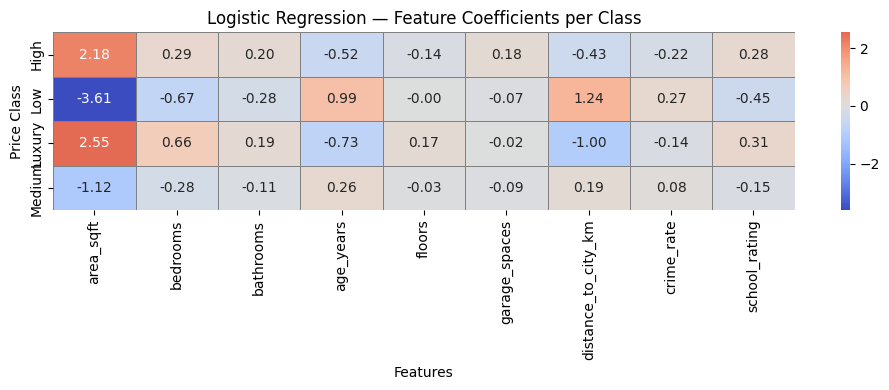

📊 Heatmap saved: lr_heatmap.png


In [ ]:
# ============================================================
#  House Price Classification — Logistic Regression
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

# ── 1. Load Data ─────────────────────────────────────────────
df = pd.read_csv("house_price_data.csv")
print("Shape:", df.shape)
print(df.head())

# ── 2. Create Target: Price Category ─────────────────────────
bins   = [0, 150000, 350000, 600000, float("inf")]
labels = ["Low", "Medium", "High", "Luxury"]

df["price_category"] = pd.cut(df["price_usd"], bins=bins, labels=labels)
print("\nClass Distribution:\n", df["price_category"].value_counts())

# ── 3. Handle Outliers (IQR cap on area_sqft) ────────────────
Q1, Q3 = df["area_sqft"].quantile([0.25, 0.75])
IQR = Q3 - Q1
df["area_sqft"] = df["area_sqft"].clip(upper=Q3 + 1.5 * IQR)

# ── 4. Features & Target ─────────────────────────────────────
X = df.drop(columns=["price_usd", "price_category"])
y = df["price_category"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

# ── 5. Train-Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# ── 6. Feature Scaling (mandatory for LR) ────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 7. Train Logistic Regression ─────────────────────────────
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

# ── 8. Evaluate ───────────────────────────────────────────────
y_pred = model.predict(X_test_sc)

print("\n✅ Accuracy :", accuracy_score(y_test, y_pred))
print("\nCross-Val Score (5-fold):",
      cross_val_score(model, X_train_sc, y_train, cv=5).mean().round(4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── 9. Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("lr_confusion_matrix.png", dpi=150)
plt.show()
print("\n📊 Plot saved: lr_confusion_matrix.png")

# ── 10. Coefficients (Feature Weights) ───────────────────────
import seaborn as sns

coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=le.classes_
)
print("\nCoefficients per Class:")
print(coef_df.T)

# ── 11. Heatmap of Coefficients ───────────────────────────────
plt.figure(figsize=(10, 4))
sns.heatmap(
    coef_df,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="gray"
)
plt.title("Logistic Regression — Feature Coefficients per Class")
plt.xlabel("Features")
plt.ylabel("Price Class")
plt.tight_layout()
plt.savefig("lr_heatmap.png", dpi=150)
plt.show()
print("📊 Heatmap saved: lr_heatmap.png")